In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             confusion_matrix, roc_auc_score,
                             classification_report)


In [4]:
df = pd.read_csv("archive/train_u6lujuX_CVtuZ9i.csv")
df.shape
display(df.head(3))

(614, 13)

In [5]:
def create_features(df):
    df = df.copy()
    df['Dependents'] = df['Dependents'].replace('3+', '3')
    df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)
    df['TotalIncome']     = df['ApplicantIncome'] + df['CoapplicantIncome']
    df['EMI']             = df['LoanAmount'] / df['Loan_Amount_Term'].replace(0, np.nan)
    df['LoanIncomeRatio'] = df['LoanAmount'] / (df['TotalIncome'] + 1)
    df['IncomePerPerson'] = df['TotalIncome'] / (df['Dependents'] + 1)
    df['Loan_Term_Years'] = df['Loan_Amount_Term'] / 12
    df['Has_Coapplicant'] = (df['CoapplicantIncome'] > 0).astype(int)
    df['EMI_to_Income']   = df['EMI'] / (df['TotalIncome'] + 1)
    return df

df = create_features(df)
print(f"Total columns: {df.shape[1]}")

Total columns: 20


In [6]:
NUMERIC_FEATURES = [
    'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
    'Loan_Amount_Term', 'TotalIncome', 'EMI',
    'LoanIncomeRatio', 'IncomePerPerson', 'Loan_Term_Years',
    'Has_Coapplicant', 'EMI_to_Income'
]

CATEGORICAL_FEATURES = [
    'Gender', 'Married', 'Dependents',
    'Education', 'Self_Employed', 
    'Property_Area', 'Credit_History'
]

print(f"Numeric     : {len(NUMERIC_FEATURES)}")
print(f"Categorical : {len(CATEGORICAL_FEATURES)}")

Numeric     : 11
Categorical : 7


In [7]:
le = LabelEncoder()
df['Loan_Status_Binary'] = le.fit_transform(df['Loan_Status'])
print(f"Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df['Loan_Status_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Encoding: {'N': np.int64(0), 'Y': np.int64(1)}
X_train : (491, 18)
X_test  : (123, 18)


In [9]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric',      numeric_pipeline,      NUMERIC_FEATURES),
    ('categorical',  categorical_pipeline,  CATEGORICAL_FEATURES)
])


In [10]:
# Model 1 — Logistic Regression (Baseline)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Model 2 — Random Forest (Intermediate)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Model 3 — XGBoost (Advanced)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
])


In [11]:
print("Training models...\n")

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression trained")

rf_pipeline.fit(X_train, y_train)
print("Random Forest trained")

xgb_pipeline.fit(X_train, y_train)
print("XGBoost trained")

print("\n All models trained successfully!")

Training models...

Logistic Regression trained
Random Forest trained
XGBoost trained

 All models trained successfully!


In [12]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    }

results = []
results.append(evaluate_model("Logistic Regression", lr_pipeline,  X_test, y_test))
results.append(evaluate_model("Random Forest",       rf_pipeline,  X_test, y_test))
results.append(evaluate_model("XGBoost",             xgb_pipeline, X_test, y_test))

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,86.18,84.00,98.82,90.81,0.8690
1,Random Forest,85.37,87.64,91.76,89.66,0.8743
2,XGBoost,82.11,85.39,89.41,87.36,0.8263


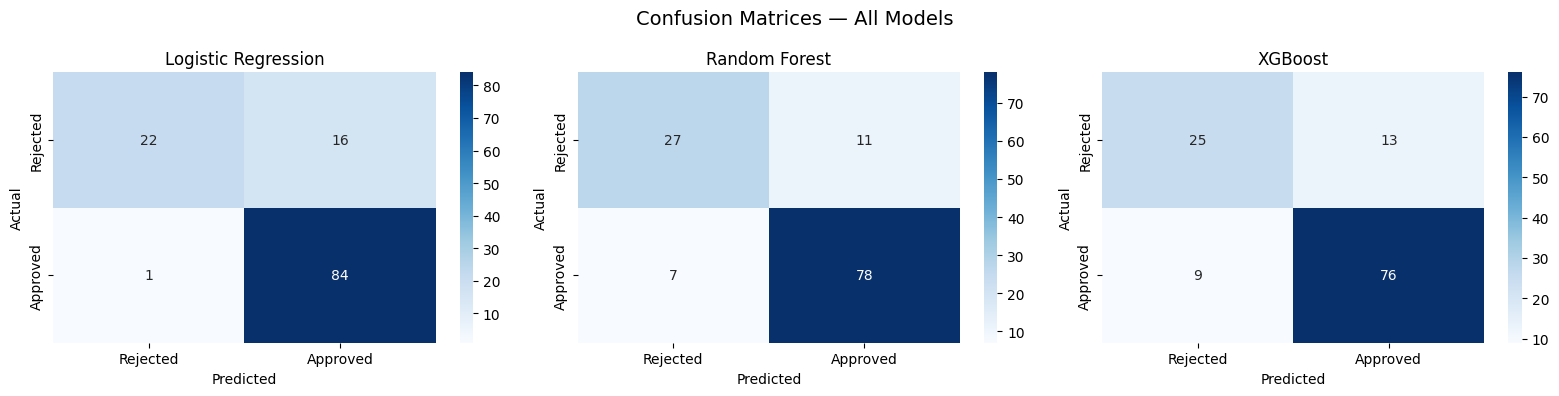

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models = [
    ("Logistic Regression", lr_pipeline),
    ("Random Forest",       rf_pipeline),
    ("XGBoost",             xgb_pipeline)
]

for ax, (name, pipeline) in zip(axes, models):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected','Approved'],
                yticklabels=['Rejected','Approved'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [15]:
import joblib

# Save all 3 pipelines
joblib.dump(lr_pipeline,  'lr_pipeline.pkl')
joblib.dump(rf_pipeline,  'rf_pipeline.pkl')
joblib.dump(xgb_pipeline, 'xgb_pipeline.pkl')

print("All models saved!")

All models saved!
